In [25]:
import numpy as np
import pandas as pd
import keras
import cv2
from matplotlib import pyplot as plt
import os
import random
from PIL import Image


In [26]:
samples = 20000
df = pd.read_csv("train.csv")
base_path = "../images/"

In [27]:
df

,id,landmark_id
0,17660ef415d37059,1
1,92b6290d571448f6,1
2,cd41bf948edc0340,1
3,fb09f1e98c6d2f70,1
4,25c9dfc7ea69838d,7
...,...,...
1580465,72c3b1c367e3d559,203092
1580466,7a6a2d9ea92684a6,203092
1580467,9401fad4c497e1f9,203092
1580468,aacc960c9a228b5f,203092


In [28]:
samples = 20000
df = df. loc[df["id"].str.startswith('00', na=False), :]
num_classes = len(df["landmark_id"].unique())
num_data = len(df)


In [29]:
num_classes

5346

In [30]:
num_data

6120

In [31]:
data = pd.DataFrame(df["landmark_id"].value_counts())
data.reset_index(inplace=True)
data.head()

,landmark_id,count
0,138982,31
1,83144,14
2,126637,7
3,194914,7
4,9673,6


In [32]:
data.tail()

,landmark_id,count
5341,202886,1
5342,202939,1
5343,202950,1
5344,202972,1
5345,202981,1


In [33]:
data.columns=['index','landmark_id']

In [34]:
data['landmark_id'].describe()

count    5346.000000
mean        1.144781
std         0.641260
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        31.000000
Name: landmark_id, dtype: float64

(array([0.000e+00, 4.781e+03, 0.000e+00, 4.520e+02, 0.000e+00, 7.500e+01,
        2.200e+01, 0.000e+00, 9.000e+00, 0.000e+00, 3.000e+00, 0.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

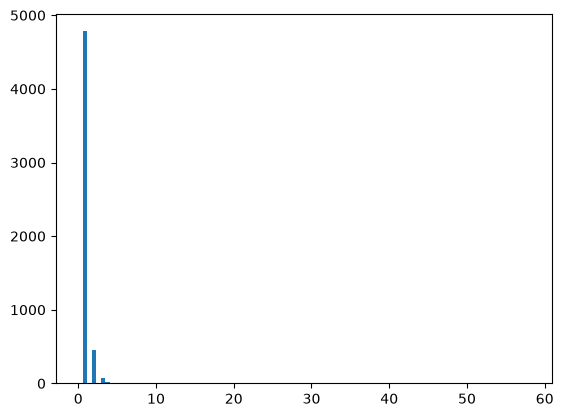

In [35]:
plt.hist(data['landmark_id'], 100, range = (0,58), label = 'test')

In [36]:
data['landmark_id'].between(0,5).sum()

np.int64(5339)

In [37]:
data['landmark_id'].between(5,10).sum()

np.int64(14)

(array([2., 1., 1., ..., 1., 1., 2.], shape=(5345,)),
 array([2.70000e+01, 6.00000e+01, 1.24000e+02, ..., 2.02950e+05,
        2.02972e+05, 2.02981e+05], shape=(5346,)),
 <BarContainer object of 5345 artists>)

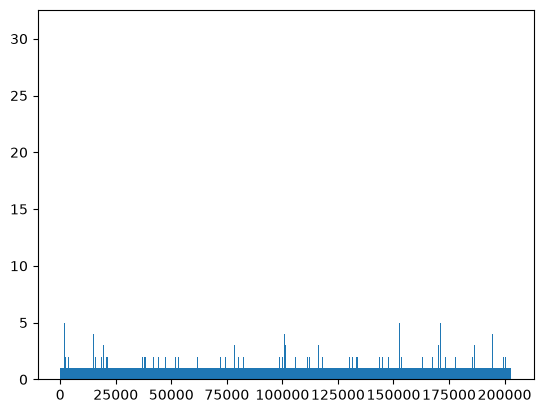

In [38]:
plt.hist(df["landmark_id"], bins=df["landmark_id"].unique())

In [39]:
from sklearn.preprocessing import LabelEncoder
lencoder = LabelEncoder()
lencoder.fit(df["landmark_id"])




Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Holds the label for each class.","ndarray[int64](5346,)","[ 27, 60, 124,...,202950,202972,202981]"


In [40]:
df.head()

,id,landmark_id
119,00cba0067c078490,27
120,00f928e383e1d121,27
796,009ecdb56b5e9adb,60
1089,00d5d47528839144,124
1133,00e9003a381ab809,134


In [41]:
def encode_label(lbl):
  return lencoder.transform(lbl)

In [ ]:
def decode_label(lbl):
  return lencoder.inverse_transform(lbl)

In [ ]:
def get_image_from_number(num):
  fname, label= df.loc[num,:]
  fname, fname + '.jpg'
  f1= fname[0]
  f2= fname[1]
  f3= fname[2]
  path = os.path.join(f1,f2,f3,fname)
  im = cv2.imread(os.path.join(base_path, path))
  return im, label

In [50]:
print(os.listdir(base_path)[:10])

['0ad063851f5f4c9e.jpg', '0ad090b466525de2.jpg', '0ad131c68b7f7dc1.jpg', '0ad1745c7a6a7292.jpg', '0ad1ada6130964ef.jpg', '0ad1b027e6a2ba53.jpg', '0ad1d477219dc4e5.jpg', '0ad222895cc42a59.jpg', '0ad2eda63186a7bb.jpg', '0ad324bf1b9d7c1d.jpg']


4 Random Sample Images


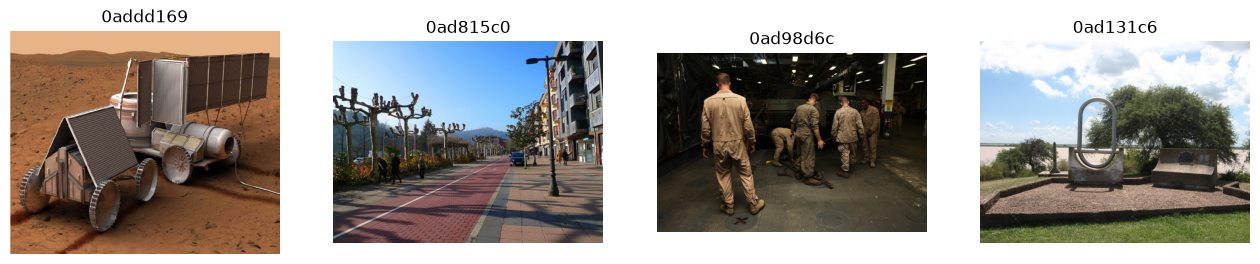

In [52]:
print("4 Random Sample Images")

fig = plt.figure(figsize=(16, 16))

image_files = os.listdir(base_path)

for i in range(1, 5):
    random_img = random.choice(image_files)

    img = np.array(Image.open(os.path.join(base_path, random_img)))

    fig.add_subplot(1, 4, i)
    plt.imshow(img)
    plt.title(random_img[:8])
    plt.axis("off")

plt.show()